# Parameter Sweep: Funding Z-Score Windows & Forward Horizons

The initial analysis used a 7-day short window, 30-day long window, and tested 1-day and 7-day forward returns. Those were arbitrary starting points. This notebook systematically tests all combinations to find which parameters (if any) produce a meaningful signal.

**Parameters we're sweeping:**
- Short window ("recent" funding): 3, 7, 14, 21 days
- Long window ("baseline" funding): 14, 30, 60, 90 days
- Forward return horizon: 1, 3, 5, 7, 14, 21 days

**What we're measuring for each combination:**
- Mean IC (rank correlation between signal and forward returns)
- Q1-Q5 spread (return of bottom quintile minus top quintile)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.size"] = 12

# Load raw data (same files from the pipeline — no need to re-download)
funding_raw = pd.read_parquet("data/funding_rates_raw.parquet")
ohlcv = pd.read_parquet("data/ohlcv_daily.parquet")

print(f"Funding records: {len(funding_raw):,}")
print(f"OHLCV candles:   {len(ohlcv):,}")
print(f"Coins: {ohlcv['symbol'].nunique()}")

Funding records: 246,384
OHLCV candles:   10,679
Coins: 30


In [2]:
# --- Step 1: Build daily funding (same for all parameter combos) ---
# This only needs to happen once since the raw daily sum doesn't change.

fr = funding_raw.copy()
fr["date"] = pd.to_datetime(fr["timestamp"]).dt.normalize()
daily_funding = fr.groupby(["symbol", "date"])["fundingRate"].sum().reset_index()
daily_funding.columns = ["symbol", "date", "daily_funding"]
daily_funding = daily_funding.sort_values(["symbol", "date"])

# --- Step 2: Precompute forward returns at all horizons ---
# This also only needs to happen once.

prices = ohlcv[["symbol", "date", "close"]].copy().sort_values(["symbol", "date"])
forward_horizons = [1, 3, 5, 7, 14, 21]

for h in forward_horizons:
    prices[f"ret_{h}d"] = prices.groupby("symbol")["close"].transform(
        lambda x: x.pct_change(h).shift(-h)
    )

# Merge daily funding with prices
base = prices.merge(daily_funding, on=["symbol", "date"], how="left")
print(f"Base dataset: {len(base):,} rows")
print(f"Forward return columns: {[c for c in base.columns if c.startswith('ret_')]}")
base.head()

Base dataset: 10,679 rows
Forward return columns: ['ret_1d', 'ret_3d', 'ret_5d', 'ret_7d', 'ret_14d', 'ret_21d']


,symbol,date,close,ret_1d,ret_3d,ret_5d,ret_7d,ret_14d,ret_21d,daily_funding
0,AAVE,2025-05-15,223.92,0.031217,0.036799,0.158673,0.148267,0.116917,0.079671,0.000075
1,AAVE,2025-05-16,230.91,-0.035252,0.073838,0.073015,0.110000,0.086960,0.086527,0.000300
2,AAVE,2025-05-17,222.77,0.042151,0.164654,0.154195,0.176011,0.108228,0.156754,0.000300
3,AAVE,2025-05-18,232.16,0.068057,0.067238,0.104023,0.159157,0.059399,0.093685,0.000300
4,AAVE,2025-05-19,247.96,0.046338,0.036941,0.056541,0.078803,0.040692,0.144338,0.000288


In [3]:
# --- Step 3: The sweep function ---
# For a given (short_window, long_window), compute the z-score,
# then measure IC and Q1-Q5 spread for each forward horizon.

def compute_zscore(df, short_w, long_w):
    """Compute funding z-score with given window parameters."""
    out = df.copy()
    grp = out.groupby("symbol")["daily_funding"]
    
    short_mean = grp.transform(lambda x: x.rolling(short_w, min_periods=max(3, short_w // 2)).mean())
    long_mean = grp.transform(lambda x: x.rolling(long_w, min_periods=max(10, long_w // 3)).mean())
    long_std = grp.transform(lambda x: x.rolling(long_w, min_periods=max(10, long_w // 3)).std())
    
    out["zscore"] = (short_mean - long_mean) / long_std
    out["zscore"] = out["zscore"].replace([np.inf, -np.inf], np.nan)
    return out


def evaluate_signal(df, ret_col):
    """Compute mean IC and Q1-Q5 spread for a given signal and return column."""
    sub = df.dropna(subset=["zscore", ret_col]).copy()
    if len(sub) < 100:
        return np.nan, np.nan
    
    # Mean IC (daily Spearman rank correlation)
    def daily_ic(g):
        if len(g) < 5:
            return np.nan
        return g["zscore"].corr(g[ret_col], method="spearman")
    
    ics = sub.groupby("date").apply(daily_ic).dropna()
    mean_ic = ics.mean() if len(ics) > 0 else np.nan
    
    # Q1-Q5 spread
    sub["quintile"] = sub.groupby("date")["zscore"].transform(
        lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") if len(x) >= 5 else np.nan
    )
    sub = sub.dropna(subset=["quintile"])
    q_means = sub.groupby("quintile")[ret_col].mean()
    
    if 0.0 in q_means.index and 4.0 in q_means.index:
        spread = (q_means[0.0] - q_means[4.0]) * 100  # in percent
    else:
        spread = np.nan
    
    return mean_ic, spread

print("Functions defined. Ready to sweep.")

Functions defined. Ready to sweep.


In [4]:
# --- Step 4: Run the sweep ---
short_windows = [3, 7, 14, 21]
long_windows = [14, 30, 60, 90]

results = []
total_combos = len(short_windows) * len(long_windows)

for i, (sw, lw) in enumerate(product(short_windows, long_windows)):
    # Skip if short window >= long window (doesn't make sense)
    if sw >= lw:
        continue
    
    print(f"  [{i+1}/{total_combos}] short={sw}d, long={lw}d", end="")
    df_z = compute_zscore(base, sw, lw)
    
    for h in forward_horizons:
        ret_col = f"ret_{h}d"
        mean_ic, spread = evaluate_signal(df_z, ret_col)
        results.append({
            "short_window": sw,
            "long_window": lw,
            "horizon": h,
            "mean_ic": mean_ic,
            "q1_q5_spread": spread,
        })
    print(" ✓")

results_df = pd.DataFrame(results)
print(f"\nDone! Tested {len(results_df)} parameter combinations.")
results_df.head(10)

  [1/16] short=3d, long=14d ✓
  [2/16] short=3d, long=30d ✓
  [3/16] short=3d, long=60d ✓
  [4/16] short=3d, long=90d ✓
  [5/16] short=7d, long=14d ✓
  [6/16] short=7d, long=30d ✓
  [7/16] short=7d, long=60d ✓
  [8/16] short=7d, long=90d ✓
  [10/16] short=14d, long=30d

/Applications/anaconda3/envs/artemis/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Applications/anaconda3/envs/artemis/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Applications/anaconda3/envs/artemis/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Applications/anaconda3/envs/artemis/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Applications/anaconda3/envs/artemis/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is co

 ✓
  [11/16] short=14d, long=60d ✓
  [12/16] short=14d, long=90d ✓
  [14/16] short=21d, long=30d

/Applications/anaconda3/envs/artemis/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Applications/anaconda3/envs/artemis/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Applications/anaconda3/envs/artemis/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Applications/anaconda3/envs/artemis/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Applications/anaconda3/envs/artemis/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is co

 ✓
  [15/16] short=21d, long=60d

/Applications/anaconda3/envs/artemis/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Applications/anaconda3/envs/artemis/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Applications/anaconda3/envs/artemis/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Applications/anaconda3/envs/artemis/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Applications/anaconda3/envs/artemis/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is co

 ✓
  [16/16] short=21d, long=90d ✓

Done! Tested 84 parameter combinations.


,short_window,long_window,horizon,mean_ic,q1_q5_spread
0,3,14,1,0.001950,-0.125690
1,3,14,3,0.009138,-0.106447
2,3,14,5,0.006184,-0.038968
3,3,14,7,0.006305,0.038255
4,3,14,14,0.014030,0.688065
5,3,14,21,0.003429,1.814051
6,3,30,1,-0.001049,-0.057468
7,3,30,3,0.011576,-0.090394
8,3,30,5,0.008267,-0.014946
9,3,30,7,0.008428,0.019657


## Results: Mean IC Heatmaps

Each heatmap shows the mean IC for one forward horizon, across all short/long window combinations. **More negative = stronger mean-reversion signal.** We want dark blue cells.

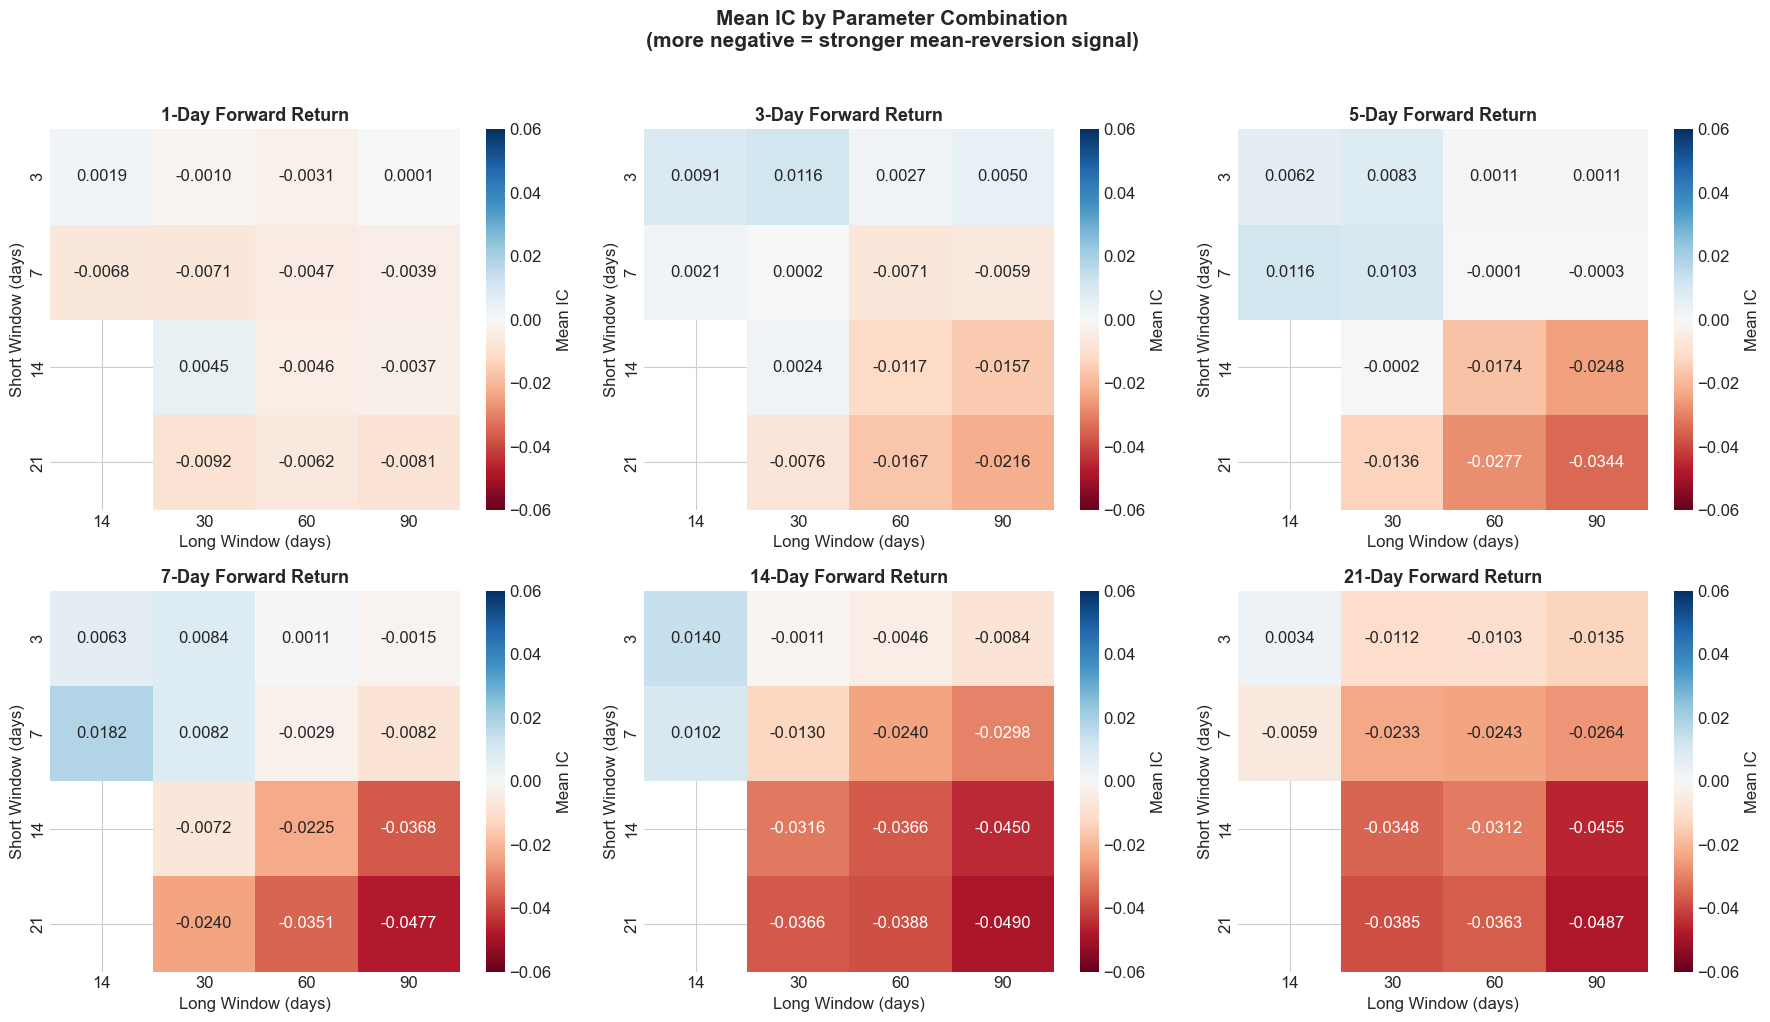

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, h in enumerate(forward_horizons):
    subset = results_df[results_df["horizon"] == h]
    pivot = subset.pivot(index="short_window", columns="long_window", values="mean_ic")
    
    sns.heatmap(
        pivot, annot=True, fmt=".4f", cmap="RdBu", center=0,
        ax=axes[idx], vmin=-0.06, vmax=0.06,
        cbar_kws={"label": "Mean IC"}
    )
    axes[idx].set_title(f"{h}-Day Forward Return", fontsize=13, fontweight="bold")
    axes[idx].set_xlabel("Long Window (days)")
    axes[idx].set_ylabel("Short Window (days)")

plt.suptitle("Mean IC by Parameter Combination\n(more negative = stronger mean-reversion signal)",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Results: Q1-Q5 Spread Heatmaps

Same layout, but showing the Q1-Q5 return spread (%). **More positive = long/short portfolio makes money.** We want dark blue cells.

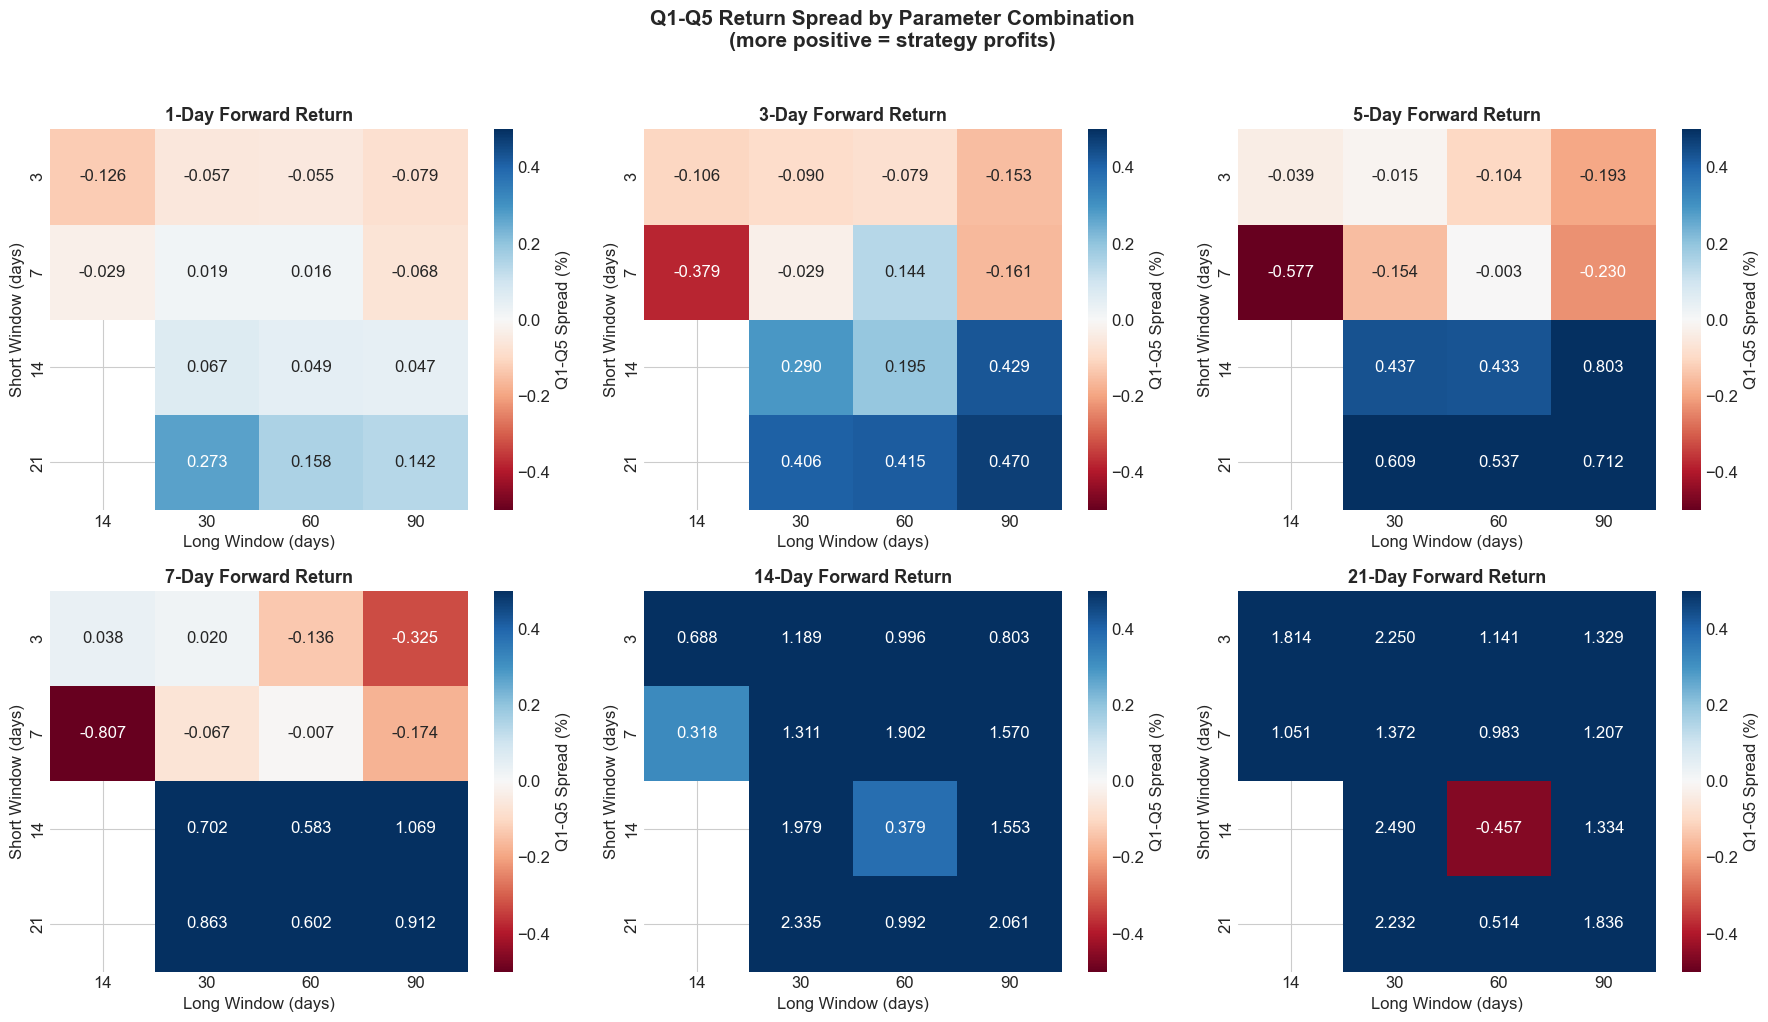

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, h in enumerate(forward_horizons):
    subset = results_df[results_df["horizon"] == h]
    pivot = subset.pivot(index="short_window", columns="long_window", values="q1_q5_spread")
    
    sns.heatmap(
        pivot, annot=True, fmt=".3f", cmap="RdBu", center=0,
        ax=axes[idx], vmin=-0.5, vmax=0.5,
        cbar_kws={"label": "Q1-Q5 Spread (%)"}
    )
    axes[idx].set_title(f"{h}-Day Forward Return", fontsize=13, fontweight="bold")
    axes[idx].set_xlabel("Long Window (days)")
    axes[idx].set_ylabel("Short Window (days)")

plt.suptitle("Q1-Q5 Return Spread by Parameter Combination\n(more positive = strategy profits)",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Top Parameter Combinations

Rank all tested combinations by mean IC and by Q1-Q5 spread to see which parameters look most promising.

In [7]:
# Best by IC (most negative = strongest mean reversion)
print("=" * 70)
print("TOP 10 BY MEAN IC (most negative = strongest mean-reversion signal)")
print("=" * 70)
top_ic = results_df.sort_values("mean_ic").head(10)
for _, row in top_ic.iterrows():
    print(f"  short={int(row['short_window']):>2d}d, long={int(row['long_window']):>2d}d, "
          f"horizon={int(row['horizon']):>2d}d  →  IC={row['mean_ic']:.4f},  "
          f"spread={row['q1_q5_spread']:.3f}%")

print()

# Best by spread (most positive = best L/S return)
print("=" * 70)
print("TOP 10 BY Q1-Q5 SPREAD (most positive = strategy makes money)")
print("=" * 70)
top_spread = results_df.sort_values("q1_q5_spread", ascending=False).head(10)
for _, row in top_spread.iterrows():
    print(f"  short={int(row['short_window']):>2d}d, long={int(row['long_window']):>2d}d, "
          f"horizon={int(row['horizon']):>2d}d  →  IC={row['mean_ic']:.4f},  "
          f"spread={row['q1_q5_spread']:.3f}%")

print()

# Highlight: do IC and spread agree on the best params?
print("=" * 70)
print("PARAMETERS APPEARING IN BOTH TOP-10 LISTS")
print("=" * 70)
top_ic_set = set(top_ic[["short_window", "long_window", "horizon"]].apply(tuple, axis=1))
top_spread_set = set(top_spread[["short_window", "long_window", "horizon"]].apply(tuple, axis=1))
overlap = top_ic_set & top_spread_set
if overlap:
    for sw, lw, h in sorted(overlap):
        row = results_df[(results_df["short_window"]==sw) & (results_df["long_window"]==lw) & (results_df["horizon"]==h)].iloc[0]
        print(f"  ★ short={int(sw):>2d}d, long={int(lw):>2d}d, horizon={int(h):>2d}d  →  IC={row['mean_ic']:.4f}, spread={row['q1_q5_spread']:.3f}%")
else:
    print("  No overlap — IC and spread favor different parameter sets.")
    print("  This is worth discussing in your report (signal may be weak across all params).")

TOP 10 BY MEAN IC (most negative = strongest mean-reversion signal)
  short=21d, long=90d, horizon=14d  →  IC=-0.0490,  spread=2.061%
  short=21d, long=90d, horizon=21d  →  IC=-0.0487,  spread=1.836%
  short=21d, long=90d, horizon= 7d  →  IC=-0.0477,  spread=0.912%
  short=14d, long=90d, horizon=21d  →  IC=-0.0455,  spread=1.334%
  short=14d, long=90d, horizon=14d  →  IC=-0.0450,  spread=1.553%
  short=21d, long=60d, horizon=14d  →  IC=-0.0388,  spread=0.992%
  short=21d, long=30d, horizon=21d  →  IC=-0.0385,  spread=2.232%
  short=14d, long=90d, horizon= 7d  →  IC=-0.0368,  spread=1.069%
  short=21d, long=30d, horizon=14d  →  IC=-0.0366,  spread=2.335%
  short=14d, long=60d, horizon=14d  →  IC=-0.0366,  spread=0.379%

TOP 10 BY Q1-Q5 SPREAD (most positive = strategy makes money)
  short=14d, long=30d, horizon=21d  →  IC=-0.0348,  spread=2.490%
  short=21d, long=30d, horizon=14d  →  IC=-0.0366,  spread=2.335%
  short= 3d, long=30d, horizon=21d  →  IC=-0.0112,  spread=2.250%
  short=21d

## Quick Backtest of Best Parameters

Take the best parameter combo from above and run a quick cumulative return chart to see if it actually looks better than the original (7d/30d).

Best params by IC: short=21d, long=90d, horizon=14d
  Mean IC: -0.0490, Q1-Q5 spread: 2.061%


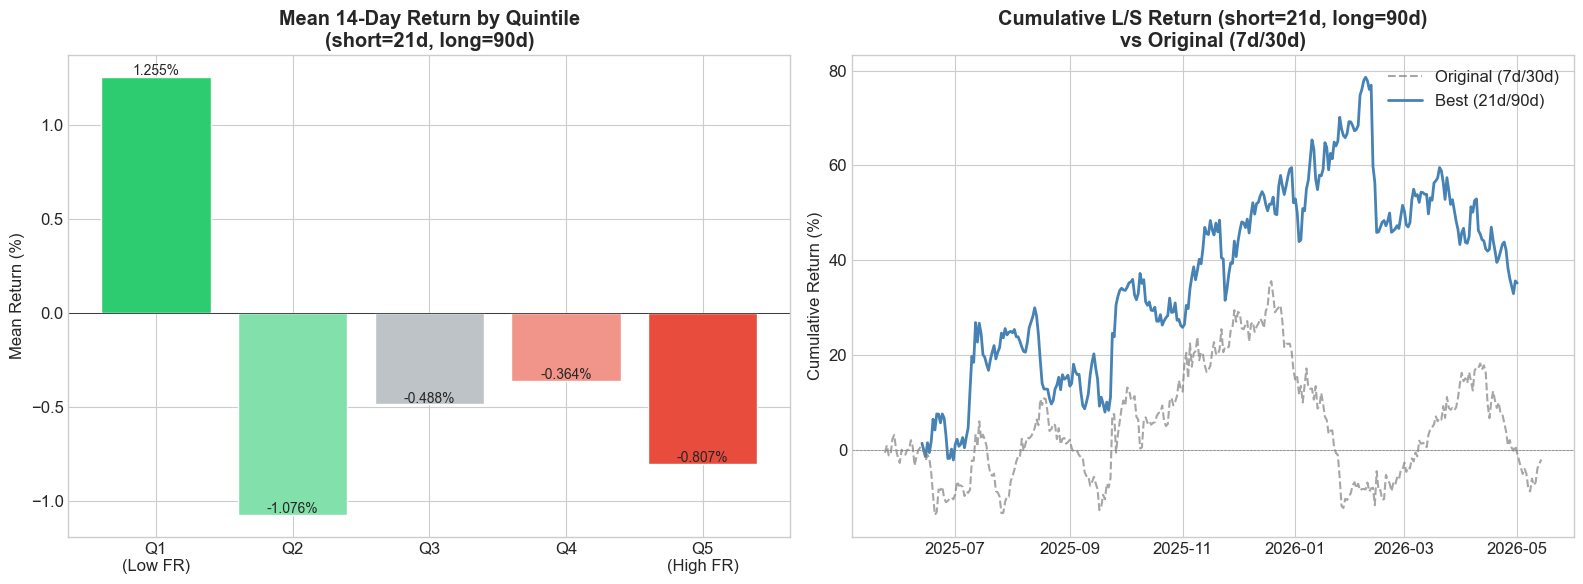


Best-param strategy performance:
  Total return:      35.23%
  Annualized return: 40.64%
  Annualized vol:    41.74%
  Sharpe ratio:      0.97
  Max drawdown:      -25.55%


In [8]:
# Pick the best combo by IC
best = results_df.loc[results_df["mean_ic"].idxmin()]
best_sw = int(best["short_window"])
best_lw = int(best["long_window"])
best_h = int(best["horizon"])
best_ret_col = f"ret_{best_h}d"

print(f"Best params by IC: short={best_sw}d, long={best_lw}d, horizon={best_h}d")
print(f"  Mean IC: {best['mean_ic']:.4f}, Q1-Q5 spread: {best['q1_q5_spread']:.3f}%")

# Recompute z-score with best params
df_best = compute_zscore(base, best_sw, best_lw)
df_best = df_best.dropna(subset=["zscore", best_ret_col]).copy()

# Assign quintiles
df_best["quintile"] = df_best.groupby("date")["zscore"].transform(
    lambda x: pd.qcut(x, 5, labels=["Q1\n(Low FR)", "Q2", "Q3", "Q4", "Q5\n(High FR)"], duplicates="drop")
)
df_best = df_best.dropna(subset=["quintile"])

# Quintile bar chart
q_returns = df_best.groupby("quintile")[best_ret_col].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ["#2ecc71", "#82e0aa", "#bdc3c7", "#f1948a", "#e74c3c"]

axes[0].bar(q_returns.index, q_returns.values, color=colors, edgecolor="white")
axes[0].set_title(f"Mean {best_h}-Day Return by Quintile\n(short={best_sw}d, long={best_lw}d)", fontweight="bold")
axes[0].set_ylabel("Mean Return (%)")
axes[0].axhline(0, color="black", linewidth=0.5)
for i, v in enumerate(q_returns.values):
    axes[0].text(i, v + 0.01, f"{v:.3f}%", ha="center", fontsize=10)

# L/S cumulative return
daily_ret = df_best.groupby(["date", "quintile"])["ret_1d"].mean().unstack()
q1_col = daily_ret.columns[0]
q5_col = daily_ret.columns[-1]
ls_ret = (daily_ret[q1_col] - daily_ret[q5_col]).dropna()
ls_cum = (1 + ls_ret).cumprod()

axes[1].plot(ls_cum.index, (ls_cum - 1) * 100, color="steelblue", linewidth=2)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.5)
axes[1].set_title(f"Cumulative L/S Return (short={best_sw}d, long={best_lw}d)\nvs Original (7d/30d)",
                   fontweight="bold")
axes[1].set_ylabel("Cumulative Return (%)")

# Overlay original 7/30 for comparison
df_orig = compute_zscore(base, 7, 30)
df_orig = df_orig.dropna(subset=["zscore", "ret_1d"]).copy()
df_orig["quintile"] = df_orig.groupby("date")["zscore"].transform(
    lambda x: pd.qcut(x, 5, labels=["Q1\n(Low FR)", "Q2", "Q3", "Q4", "Q5\n(High FR)"], duplicates="drop")
)
df_orig = df_orig.dropna(subset=["quintile"])
daily_orig = df_orig.groupby(["date", "quintile"])["ret_1d"].mean().unstack()
ls_orig = (daily_orig[daily_orig.columns[0]] - daily_orig[daily_orig.columns[-1]]).dropna()
ls_cum_orig = (1 + ls_orig).cumprod()
axes[1].plot(ls_cum_orig.index, (ls_cum_orig - 1) * 100, color="gray", linewidth=1.5, 
             linestyle="--", alpha=0.7, label="Original (7d/30d)")
axes[1].plot([], [], color="steelblue", linewidth=2, label=f"Best ({best_sw}d/{best_lw}d)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Stats
total_ret = ls_cum.iloc[-1] - 1
ann_vol = ls_ret.std() * np.sqrt(365)
ann_ret = (1 + total_ret) ** (365 / len(ls_ret)) - 1
sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
max_dd = (ls_cum / ls_cum.cummax() - 1).min()

print(f"\nBest-param strategy performance:")
print(f"  Total return:      {total_ret:.2%}")
print(f"  Annualized return: {ann_ret:.2%}")
print(f"  Annualized vol:    {ann_vol:.2%}")
print(f"  Sharpe ratio:      {sharpe:.2f}")
print(f"  Max drawdown:      {max_dd:.2%}")

## Interpreting the Results

Look at the heatmaps and top-10 lists above:

**If one region of the heatmap is clearly darker (more negative IC / more positive spread):**
The signal exists but you had the wrong parameters. Update `data_pipeline.py` with the best short/long window and re-run `signal_analysis.ipynb` with that horizon.

**If the heatmaps are mostly flat near zero:**
The funding z-score doesn't work at *any* parameter set as a standalone signal. This is a valid finding — write it up honestly and pivot to a multi-factor approach (combine funding with momentum, volume, or on-chain data from Artemis).

**If the best IC and best spread disagree on parameters:**
The signal might have a weak linear relationship (IC) but still separate extremes (spread), or vice versa. Worth investigating the shape of the signal-return relationship (is it nonlinear?).